# EDA 9.1: Stockout Analysis

This notebook analyzes stockouts by product, category, and month, compares stockout pressure with unusually low Revenue periods, and prepares leakage-safe inventory features for daily Revenue forecasting. Inventory appears monthly in this dataset, so stockout metrics are aggregated at month level first and then lagged before merging into daily Revenue rows.

## 1. Setup and File Discovery

Locate `inventory.csv`, `products.csv`, and `sales.csv` anywhere under the current working directory. Missing files produce warnings and the notebook continues where possible.

In [1]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('default')
pd.set_option('display.max_columns', 180)
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

ROOT = Path.cwd()
FILES = ['inventory.csv', 'products.csv', 'sales.csv']

def normalize_name(name):
    return re.sub(r'[^a-z0-9]+', '', str(name).strip().lower())

def safe_label(value):
    label = re.sub(r'[^a-z0-9]+', '_', str(value).strip().lower()).strip('_')
    return label or 'unknown'

def discover_csvs(root):
    found = {}
    for path in root.rglob('*.csv'):
        key = path.name.lower()
        if key not in found:
            found[key] = path
    return found

csv_files = discover_csvs(ROOT)
selected_paths = {name: csv_files.get(name.lower()) for name in FILES}
file_status = pd.DataFrame([
    {'file': name, 'found': path is not None, 'path': str(path) if path else None}
    for name, path in selected_paths.items()
])
display(file_status)

for name, path in selected_paths.items():
    if path is None:
        warnings.warn(f'{name} was not found. The notebook will continue where possible.')

,file,found,path
0,inventory.csv,True,D:\Code\Datathon 2026\datathon-2026-round-1\in...
1,products.csv,True,D:\Code\Datathon 2026\datathon-2026-round-1\pr...
2,sales.csv,True,D:\Code\Datathon 2026\datathon-2026-round-1\sa...


## 2. Load Inventory, Products, and Sales

Load each available CSV safely with pandas and display the raw schemas.

In [2]:
def safe_read_csv(path, name):
    if path is None:
        return None
    try:
        df = pd.read_csv(path, low_memory=False)
        print(f'Loaded {name}: {df.shape[0]:,} rows x {df.shape[1]:,} columns from {path}')
        return df
    except Exception as exc:
        warnings.warn(f'Could not load {name} from {path}: {exc}')
        return None

inventory_raw = safe_read_csv(selected_paths.get('inventory.csv'), 'inventory.csv')
products_raw = safe_read_csv(selected_paths.get('products.csv'), 'products.csv')
sales_raw = safe_read_csv(selected_paths.get('sales.csv'), 'sales.csv')

schema_rows = []
for name, df in [('inventory.csv', inventory_raw), ('products.csv', products_raw), ('sales.csv', sales_raw)]:
    if df is not None:
        schema_rows.append({'file': name, 'rows': len(df), 'columns': len(df.columns), 'column_names': ', '.join(map(str, df.columns))})
schema_overview = pd.DataFrame(schema_rows)
display(schema_overview)

Loaded inventory.csv: 60,247 rows x 17 columns from D:\Code\Datathon 2026\datathon-2026-round-1\inventory.csv
Loaded products.csv: 2,412 rows x 8 columns from D:\Code\Datathon 2026\datathon-2026-round-1\products.csv
Loaded sales.csv: 3,833 rows x 3 columns from D:\Code\Datathon 2026\datathon-2026-round-1\sales.csv


,file,rows,columns,column_names
0,inventory.csv,60247,17,"snapshot_date, product_id, stock_on_hand, unit..."
1,products.csv,2412,8,"product_id, product_name, category, segment, s..."
2,sales.csv,3833,3,"Date, Revenue, COGS"


## 3. Identify Inventory, Product, Category, Date, Stockout, Fill-Rate, and Revenue Columns

Column matching normalizes case, spaces, punctuation, and underscores, then uses candidate names and keyword scoring for minor naming differences.

In [3]:
def column_lookup(df):
    if df is None:
        return {}
    return {normalize_name(c): c for c in df.columns}

def find_col(df, candidates=None, include_all=None, include_any=None, exclude_any=None, prefer_numeric=False):
    if df is None:
        return None
    candidates = candidates or []
    include_all = [normalize_name(x) for x in (include_all or [])]
    include_any = [normalize_name(x) for x in (include_any or [])]
    exclude_any = [normalize_name(x) for x in (exclude_any or [])]
    lookup = column_lookup(df)
    for cand in candidates:
        key = normalize_name(cand)
        if key in lookup:
            return lookup[key]
    scored = []
    for col in df.columns:
        key = normalize_name(col)
        if exclude_any and any(x in key for x in exclude_any):
            continue
        if include_all and not all(x in key for x in include_all):
            continue
        if include_any and not any(x in key for x in include_any):
            continue
        score = sum(3 for x in include_all if x in key) + sum(2 for x in include_any if x in key)
        if prefer_numeric and pd.api.types.is_numeric_dtype(df[col]):
            score += 1
        scored.append((score, len(key), col))
    if scored:
        scored.sort(key=lambda x: (-x[0], x[1], str(x[2])))
        return scored[0][2]
    return None

def to_num(s):
    return pd.to_numeric(s, errors='coerce')

def infer_revenue_col(df):
    if df is None:
        return None
    direct = find_col(
        df,
        ['revenue', 'total_revenue', 'sales_amount', 'sales', 'net_sales', 'amount'],
        include_any=['revenue', 'salesamount', 'totalsales', 'netsales'],
        exclude_any=['cost', 'cogs', 'margin', 'profit', 'tax'],
        prefer_numeric=True,
    )
    if direct is not None:
        return direct
    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) or to_num(df[c]).notna().mean() > 0.8]
    candidates = []
    for c in numeric_cols:
        key = normalize_name(c)
        if any(x in key for x in ['cost', 'cogs', 'margin', 'profit', 'tax', 'id']):
            continue
        vals = to_num(df[c])
        candidates.append(((vals > 0).mean(), vals.abs().sum(skipna=True), c))
    if candidates:
        candidates.sort(key=lambda x: (-x[0], -x[1], str(x[2])))
        warnings.warn(f'Revenue column was not explicit; using likely numeric revenue column: {candidates[0][2]}')
        return candidates[0][2]
    return None

cols = {}
if inventory_raw is not None:
    cols['inv_product_id'] = find_col(inventory_raw, ['product_id', 'productid', 'sku_id', 'item_id'], include_any=['productid', 'skuid', 'itemid'])
    cols['inv_date'] = find_col(inventory_raw, ['snapshot_date', 'inventory_date', 'date', 'month_end_date'], include_any=['snapshotdate', 'inventorydate', 'date'])
    cols['inv_year'] = find_col(inventory_raw, ['year'], include_any=['year'], prefer_numeric=True)
    cols['inv_month'] = find_col(inventory_raw, ['month'], include_any=['month'], prefer_numeric=True)
    cols['stock_qty'] = find_col(inventory_raw, ['stock_on_hand', 'on_hand_qty', 'stock_qty', 'available_inventory', 'inventory_qty', 'quantity_on_hand'], include_any=['stockonhand', 'onhandqty', 'stockqty', 'availableinventory', 'inventoryqty', 'quantityonhand'], prefer_numeric=True)
    cols['stockout_flag'] = find_col(inventory_raw, ['stockout_flag', 'out_of_stock_flag', 'oos_flag', 'stockout_indicator'], include_any=['stockoutflag', 'outofstockflag', 'oosflag', 'stockoutindicator'], prefer_numeric=True)
    cols['stockout_days'] = find_col(inventory_raw, ['stockout_days', 'oos_days', 'days_out_of_stock'], include_any=['stockoutdays', 'oosdays', 'daysoutofstock'], prefer_numeric=True)
    cols['fill_rate'] = find_col(inventory_raw, ['fill_rate', 'availability_rate', 'service_level'], include_any=['fillrate', 'availabilityrate', 'servicelevel'], prefer_numeric=True)
    cols['units_sold'] = find_col(inventory_raw, ['units_sold', 'qty_sold', 'sales_units'], include_any=['unitssold', 'qtysold', 'salesunits'], prefer_numeric=True)
    cols['inv_category'] = find_col(inventory_raw, ['category', 'product_category'], include_any=['category'])
    cols['inv_segment'] = find_col(inventory_raw, ['segment', 'product_segment'], include_any=['segment'])
if products_raw is not None:
    cols['prod_product_id'] = find_col(products_raw, ['product_id', 'productid', 'sku_id', 'item_id'], include_any=['productid', 'skuid', 'itemid'])
    cols['prod_category'] = find_col(products_raw, ['category', 'product_category'], include_any=['category'])
    cols['prod_segment'] = find_col(products_raw, ['segment', 'product_segment'], include_any=['segment'])
if sales_raw is not None:
    cols['sales_date'] = find_col(sales_raw, ['date', 'sales_date', 'order_date', 'revenue_date'], include_any=['date', 'day'])
    cols['revenue'] = infer_revenue_col(sales_raw)
    cols['sales_product_id'] = find_col(sales_raw, ['product_id', 'productid', 'sku_id', 'item_id'], include_any=['productid', 'skuid', 'itemid'])

identified_columns = pd.DataFrame([{'role': k, 'column': v} for k, v in cols.items()])
display(identified_columns)

,role,column
0,inv_product_id,product_id
1,inv_date,snapshot_date
2,inv_year,year
3,inv_month,month
4,stock_qty,stock_on_hand
5,stockout_flag,stockout_flag
6,stockout_days,stockout_days
7,fill_rate,fill_rate
8,units_sold,units_sold
9,inv_category,category


## 4. Inventory Data Quality Checks

Inspect inventory date coverage, granularity, duplicate product-period rows, missing values, and likely inventory cadence.

In [4]:
inventory = pd.DataFrame()
inventory_warnings = []
inventory_granularity = 'unknown'

if inventory_raw is None or inventory_raw.empty:
    inventory_warnings.append('inventory.csv is missing or empty.')
elif cols.get('inv_product_id') is None:
    inventory_warnings.append('Inventory product ID column could not be identified.')
else:
    inventory = inventory_raw.copy()
    if cols.get('inv_date'):
        inventory['inventory_date'] = pd.to_datetime(inventory[cols['inv_date']], errors='coerce').dt.floor('D')
    elif cols.get('inv_year') and cols.get('inv_month'):
        inventory['inventory_date'] = pd.to_datetime(
            inventory[cols['inv_year']].astype('Int64').astype(str) + '-' + inventory[cols['inv_month']].astype('Int64').astype(str).str.zfill(2) + '-01',
            errors='coerce'
        ) + pd.offsets.MonthEnd(0)
    else:
        inventory['inventory_date'] = pd.NaT
        inventory_warnings.append('Inventory date/month could not be identified.')
    inventory['product_id_std'] = inventory[cols['inv_product_id']].astype('string').str.strip()
    if cols.get('stock_qty'):
        inventory['inventory_qty'] = to_num(inventory[cols['stock_qty']])
    if cols.get('stockout_flag'):
        inventory['stockout_flag_raw'] = to_num(inventory[cols['stockout_flag']])
    if cols.get('stockout_days'):
        inventory['stockout_days_raw'] = to_num(inventory[cols['stockout_days']])
    if cols.get('fill_rate'):
        fr = to_num(inventory[cols['fill_rate']])
        inventory['fill_rate_raw'] = np.where(fr.abs() > 1.5, fr / 100.0, fr)
    if cols.get('units_sold'):
        inventory['units_sold_raw'] = to_num(inventory[cols['units_sold']])

    if inventory['inventory_date'].notna().sum() >= 2:
        diffs = inventory[['inventory_date']].dropna().sort_values('inventory_date')['inventory_date'].diff().dropna().dt.days
        if not diffs.empty:
            med = diffs.median()
            inventory_granularity = 'monthly' if med >= 25 else ('daily' if med <= 2 else 'irregular')
        else:
            inventory_granularity = 'single_period'

    duplicate_product_period = int(inventory.duplicated(['product_id_std', 'inventory_date']).sum()) if 'inventory_date' in inventory else np.nan
    report = pd.DataFrame([
        {'metric': 'inventory_date_range_start', 'value': inventory['inventory_date'].min()},
        {'metric': 'inventory_date_range_end', 'value': inventory['inventory_date'].max()},
        {'metric': 'inventory_rows', 'value': len(inventory)},
        {'metric': 'inventory_products', 'value': inventory['product_id_std'].nunique(dropna=True)},
        {'metric': 'missing_product_ids', 'value': int(inventory['product_id_std'].isna().sum())},
        {'metric': 'missing_inventory_dates', 'value': int(inventory['inventory_date'].isna().sum())},
        {'metric': 'missing_stock_quantity', 'value': int(inventory['inventory_qty'].isna().sum()) if 'inventory_qty' in inventory else np.nan},
        {'metric': 'missing_stockout_flag', 'value': int(inventory['stockout_flag_raw'].isna().sum()) if 'stockout_flag_raw' in inventory else np.nan},
        {'metric': 'missing_fill_rate', 'value': int(inventory['fill_rate_raw'].isna().sum()) if 'fill_rate_raw' in inventory else np.nan},
        {'metric': 'duplicate_product_date_rows', 'value': duplicate_product_period},
        {'metric': 'detected_granularity', 'value': inventory_granularity},
    ])
    display(report)
    display(inventory.head())
    numeric_cols = [c for c in ['inventory_qty', 'stockout_flag_raw', 'stockout_days_raw', 'fill_rate_raw', 'units_sold_raw'] if c in inventory.columns]
    if numeric_cols:
        display(inventory[numeric_cols].describe().T)

if inventory_warnings:
    print('Inventory warnings:')
    for w in inventory_warnings:
        print('-', w)

,metric,value
0,inventory_date_range_start,2012-07-31 00:00:00
1,inventory_date_range_end,2022-12-31 00:00:00
2,inventory_rows,60247
3,inventory_products,1624
4,missing_product_ids,0
5,missing_inventory_dates,0
6,missing_stock_quantity,0
7,missing_stockout_flag,0
8,missing_fill_rate,0
9,duplicate_product_date_rows,0


,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,product_name,category,segment,year,month,inventory_date,product_id_std,inventory_qty,stockout_flag_raw,stockout_days_raw,fill_rate_raw,units_sold_raw
0,2022-10-31,1,3,1,1,2,90.0000,0.9333,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,10,2022-10-31,1,3,1,2,0.9333,1
1,2022-11-30,1,3,1,1,1,90.0000,0.9667,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,11,2022-11-30,1,3,1,1,0.9667,1
2,2022-12-31,1,3,1,1,1,90.0000,0.9667,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,12,2022-12-31,1,3,1,1,0.9667,1
3,2016-04-30,3,35,13,11,2,95.5000,0.9333,1,1,0,0.2391,DragonWear MA-03,Casual,All-weather,2016,4,2016-04-30,3,35,1,2,0.9333,11
4,2016-05-31,3,36,11,10,1,108.0000,0.9667,1,1,0,0.2174,DragonWear MA-03,Casual,All-weather,2016,5,2016-05-31,3,36,1,1,0.9667,10


,count,mean,std,min,25%,50%,75%,max
inventory_qty,"60,247.0000",189.2985,316.9761,3.0000,15.0000,62.0000,210.0000,"2,673.0000"
stockout_flag_raw,"60,247.0000",0.6734,0.4690,0.0000,0.0000,1.0000,1.0000,1.0000
stockout_days_raw,"60,247.0000",1.1606,1.6245,0.0000,0.0000,1.0000,2.0000,28.0000
fill_rate_raw,"60,247.0000",0.9613,0.0542,0.0667,0.9333,0.9667,1.0000,1.0000
units_sold_raw,"60,247.0000",15.4178,28.4044,1.0000,2.0000,6.0000,16.0000,670.0000


## 5. Join Inventory with Products

Join inventory to products by product ID, bring in category and segment when available, and report join quality. Inventory already contains category fields in this dataset, but the product join is still validated explicitly.

In [5]:
inventory_joined = pd.DataFrame()
join_quality = pd.DataFrame()

if inventory.empty:
    print('Inventory data is unavailable; product join cannot be computed.')
else:
    inventory_joined = inventory.copy()
    unmatched_samples = pd.DataFrame()
    if products_raw is not None and cols.get('prod_product_id'):
        prod = products_raw.copy()
        prod['product_id_std'] = prod[cols['prod_product_id']].astype('string').str.strip()
        prod_keep = ['product_id_std']
        for c in [cols.get('prod_category'), cols.get('prod_segment')]:
            if c and c not in prod_keep:
                prod_keep.append(c)
        prod = prod[prod_keep].drop_duplicates('product_id_std')
        inventory_joined = inventory_joined.merge(prod, on='product_id_std', how='left', suffixes=('', '_prod'))
        matched = int(inventory_joined['product_id_std'].notna().sum() - inventory_joined[cols.get('prod_category')] .isna().sum()) if cols.get('prod_category') and cols.get('prod_category') in inventory_joined.columns else int(inventory_joined['product_id_std'].isin(set(prod['product_id_std'])).sum())
        unmatched = int(len(inventory_joined) - matched)
        products_without_inventory = int(len(prod.loc[~prod['product_id_std'].isin(set(inventory_joined['product_id_std'].dropna()))]))
        if matched < len(inventory_joined):
            unmatched_samples = inventory_joined.loc[~inventory_joined['product_id_std'].isin(set(prod['product_id_std'])), ['product_id_std']].drop_duplicates().head(20)
        join_quality = pd.DataFrame([
            {'metric': 'inventory_rows_matched_to_products', 'value': matched},
            {'metric': 'inventory_rows_unmatched_to_products', 'value': unmatched},
            {'metric': 'products_without_inventory_records', 'value': products_without_inventory},
        ])
        display(join_quality)
        if not unmatched_samples.empty:
            print('Sample unmatched product IDs:')
            display(unmatched_samples)
    else:
        print('Products file or product key is unavailable; join quality cannot be fully evaluated.')
        inventory_joined = inventory.copy()

,metric,value
0,inventory_rows_matched_to_products,60247
1,inventory_rows_unmatched_to_products,0
2,products_without_inventory_records,788


## 6. Define Stockout Metrics

Create stockout indicators from existing fields when present, otherwise infer stockouts from inventory quantity at or below zero. The resulting month-level stockout metrics become the base for later Revenue comparisons and lagged forecast features.

In [6]:
stockout_definition = ''
if inventory_joined.empty:
    print('Inventory data is unavailable; stockout metrics cannot be defined.')
else:
    inv = inventory_joined.copy()
    if 'stockout_flag_raw' in inv.columns and inv['stockout_flag_raw'].notna().any():
        inv['stockout_flag_final'] = inv['stockout_flag_raw'].fillna(0) > 0
        stockout_definition = 'Used existing stockout_flag field when available.'
    elif 'stockout_days_raw' in inv.columns and inv['stockout_days_raw'].notna().any():
        inv['stockout_flag_final'] = inv['stockout_days_raw'].fillna(0) > 0
        stockout_definition = 'Inferred stockout_flag from stockout_days > 0 because explicit stockout_flag was unavailable.'
    elif 'inventory_qty' in inv.columns:
        inv['stockout_flag_final'] = inv['inventory_qty'].fillna(0) <= 0
        stockout_definition = 'Inferred stockout_flag from inventory quantity <= 0 because explicit stockout fields were unavailable.'
    else:
        inv['stockout_flag_final'] = pd.NA
        stockout_definition = 'Stockout flag could not be defined because no stock quantity or stockout field was identified.'

    inv['inferred_stockout_flag'] = inv['inventory_qty'].fillna(0) <= 0 if 'inventory_qty' in inv.columns else pd.NA
    inv['available_flag'] = inv['inventory_qty'].fillna(0) > 0 if 'inventory_qty' in inv.columns else pd.NA
    inv['year_month'] = inv['inventory_date'].dt.to_period('M').astype('string') if 'inventory_date' in inv.columns else pd.NA

    # Prefer inventory category, fall back to products join.
    cat_col = cols.get('inv_category') if cols.get('inv_category') in inv.columns else None
    prod_cat_col = cols.get('prod_category') if cols.get('prod_category') in inv.columns else None
    if cat_col:
        inv['category_final'] = inv[cat_col].astype('string').fillna('Unknown')
    elif prod_cat_col:
        inv['category_final'] = inv[prod_cat_col].astype('string').fillna('Unknown')
    else:
        inv['category_final'] = 'Unknown'
        inventory_warnings.append('Product category could not be identified; category-level stockout analysis will be limited.')

    seg_col = cols.get('inv_segment') if cols.get('inv_segment') in inv.columns else None
    prod_seg_col = cols.get('prod_segment') if cols.get('prod_segment') in inv.columns else None
    if seg_col:
        inv['segment_final'] = inv[seg_col].astype('string').fillna('Unknown')
    elif prod_seg_col:
        inv['segment_final'] = inv[prod_seg_col].astype('string').fillna('Unknown')
    else:
        inv['segment_final'] = pd.NA

    inventory_joined = inv
    print('Stockout definition used:')
    print(stockout_definition)
    display(inventory_joined[['inventory_date', 'product_id_std', 'category_final', 'inventory_qty', 'stockout_flag_final', 'inferred_stockout_flag']].head())

Stockout definition used:
Used existing stockout_flag field when available.


,inventory_date,product_id_std,category_final,inventory_qty,stockout_flag_final,inferred_stockout_flag
0,2022-10-31,1,Casual,3,True,False
1,2022-11-30,1,Casual,3,True,False
2,2022-12-31,1,Casual,3,True,False
3,2016-04-30,3,Casual,35,True,False
4,2016-05-31,3,Casual,36,True,False


## 7. Monthly Stockout Aggregation

Aggregate inventory to month-level stockout metrics. Inventory is treated as month-level in this notebook, so daily Revenue rows will later inherit lagged month-level inventory signals by year-month.

In [7]:
monthly_stockout = pd.DataFrame()
category_month_stockout = pd.DataFrame()

if inventory_joined.empty or 'year_month' not in inventory_joined.columns:
    print('Inventory data is unavailable; monthly stockout aggregation cannot be computed.')
else:
    inv = inventory_joined.dropna(subset=['year_month']).copy()
    agg_rows = []
    for ym, g in inv.groupby('year_month'):
        row = {
            'year_month': ym,
            'month_start': pd.Period(ym).to_timestamp(),
            'total_product_month_records': len(g),
            'stockout_product_month_count': int(g['stockout_flag_final'].fillna(False).sum()) if 'stockout_flag_final' in g else np.nan,
            'number_of_stockout_products': int(g.loc[g['stockout_flag_final'].fillna(False), 'product_id_std'].nunique()) if 'stockout_flag_final' in g else np.nan,
            'average_inventory_qty': g['inventory_qty'].mean() if 'inventory_qty' in g else np.nan,
            'median_inventory_qty': g['inventory_qty'].median() if 'inventory_qty' in g else np.nan,
            'average_fill_rate': g['fill_rate_raw'].mean() if 'fill_rate_raw' in g else np.nan,
            'stockout_days': g['stockout_days_raw'].sum() if 'stockout_days_raw' in g else np.nan,
            'stockout_days_per_product': g['stockout_days_raw'].sum() / g['product_id_std'].nunique() if 'stockout_days_raw' in g and g['product_id_std'].nunique() else np.nan,
        }
        row['stockout_rate'] = row['stockout_product_month_count'] / row['total_product_month_records'] if row['total_product_month_records'] else np.nan
        agg_rows.append(row)
    monthly_stockout = pd.DataFrame(agg_rows).sort_values('month_start')
    display(monthly_stockout)

    cat_rows = []
    for (ym, cat), g in inv.groupby(['year_month', 'category_final']):
        row = {
            'year_month': ym,
            'month_start': pd.Period(ym).to_timestamp(),
            'category_final': cat,
            'inventory_records': len(g),
            'stockout_count': int(g['stockout_flag_final'].fillna(False).sum()),
            'stockout_rate': g['stockout_flag_final'].fillna(False).mean(),
            'avg_inventory_qty': g['inventory_qty'].mean() if 'inventory_qty' in g else np.nan,
            'avg_fill_rate': g['fill_rate_raw'].mean() if 'fill_rate_raw' in g else np.nan,
            'stockout_days': g['stockout_days_raw'].sum() if 'stockout_days_raw' in g else np.nan,
        }
        cat_rows.append(row)
    category_month_stockout = pd.DataFrame(cat_rows).sort_values(['month_start', 'category_final'])
    display(category_month_stockout.head(20))

,year_month,month_start,total_product_month_records,stockout_product_month_count,number_of_stockout_products,average_inventory_qty,median_inventory_qty,average_fill_rate,stockout_days,stockout_days_per_product,stockout_rate
0,2012-07,2012-07-01,395,264,264,59.9949,25.0000,0.9661,402,1.0177,0.6684
1,2012-08,2012-08-01,423,300,300,62.0544,27.0000,0.9449,699,1.6525,0.7092
2,2012-09,2012-09-01,424,274,274,64.9033,30.0000,0.9500,636,1.5000,0.6462
3,2012-10,2012-10-01,437,282,282,66.8055,30.0000,0.9526,621,1.4211,0.6453
4,2012-11,2012-11-01,411,295,295,73.3187,34.0000,0.9599,495,1.2044,0.7178
...,...,...,...,...,...,...,...,...,...,...,...
121,2022-08,2022-08-01,461,301,301,227.5141,50.0000,0.9652,481,1.0434,0.6529
122,2022-09,2022-09-01,419,269,269,256.1074,60.0000,0.9670,415,0.9905,0.6420
123,2022-10,2022-10-01,409,268,268,254.9022,59.0000,0.9618,469,1.1467,0.6553
124,2022-11,2022-11-01,376,262,262,252.6676,56.0000,0.9599,452,1.2021,0.6968


,year_month,month_start,category_final,inventory_records,stockout_count,stockout_rate,avg_inventory_qty,avg_fill_rate,stockout_days
0,2012-07,2012-07-01,Casual,16,12,0.7500,31.0625,0.9604,19
1,2012-07,2012-07-01,GenZ,15,12,0.8000,87.6000,0.9578,19
2,2012-07,2012-07-01,Outdoor,145,87,0.6000,56.5310,0.9685,137
3,2012-07,2012-07-01,Streetwear,219,153,0.6986,62.5114,0.9654,227
4,2012-08,2012-08-01,Casual,17,9,0.5294,31.4118,0.9745,13
5,2012-08,2012-08-01,GenZ,20,14,0.7000,73.1500,0.9683,19
6,2012-08,2012-08-01,Outdoor,151,105,0.6954,60.3642,0.9534,211
7,2012-08,2012-08-01,Streetwear,235,172,0.7319,64.4128,0.9353,456
8,2012-09,2012-09-01,Casual,17,11,0.6471,33.0000,0.9667,17
9,2012-09,2012-09-01,GenZ,19,16,0.8421,79.2632,0.9561,25


## 8. Stockout by Category

Compare stockout rate, stockout count, inventory quantity, and fill rate by category. Small-sample categories are flagged for cautious interpretation.

,category_final,number_of_products,inventory_records,stockout_count,stockout_rate,average_inventory_qty,average_fill_rate,highest_stockout_month,highest_month_stockout_rate,small_sample_flag
1,GenZ,113,4674,3192,0.6829,125.1085,0.9617,2013-12,0.8750,False
2,Outdoor,502,21050,14177,0.6735,225.6480,0.9627,2016-05,0.7554,False
3,Streetwear,890,31020,20883,0.6732,185.6703,0.9602,2013-02,0.7455,False
0,Casual,119,3503,2319,0.6620,88.6446,0.9618,2013-11,1.0000,True


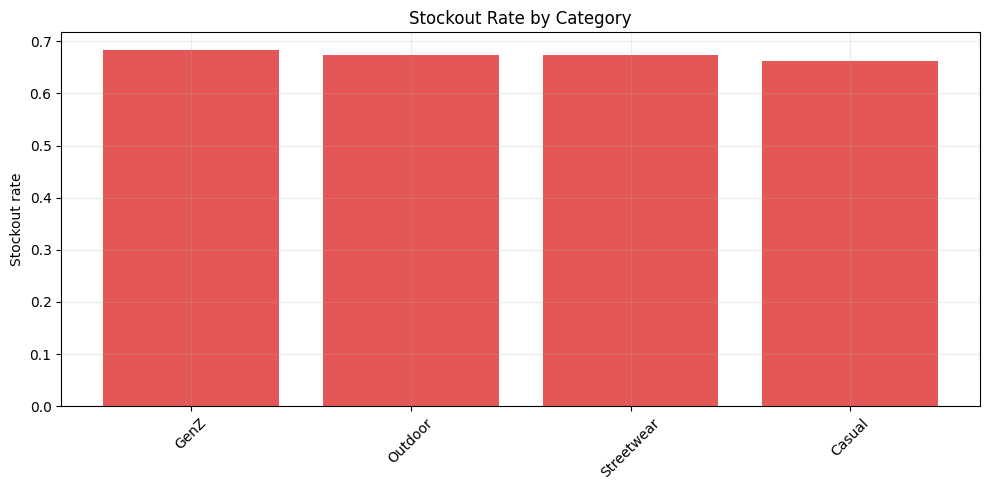

In [8]:
category_stockout = pd.DataFrame()
if inventory_joined.empty or 'category_final' not in inventory_joined.columns:
    print('Category data is unavailable; category-level stockout analysis cannot be computed.')
else:
    inv = inventory_joined.copy()
    category_stockout = inv.groupby('category_final').agg(
        number_of_products=('product_id_std', 'nunique'),
        inventory_records=('product_id_std', 'count'),
        stockout_count=('stockout_flag_final', lambda s: int(s.fillna(False).sum())),
        stockout_rate=('stockout_flag_final', lambda s: s.fillna(False).mean()),
        average_inventory_qty=('inventory_qty', 'mean'),
        average_fill_rate=('fill_rate_raw', 'mean'),
    ).reset_index()
    highest_months = category_month_stockout.sort_values(['category_final', 'stockout_rate'], ascending=[True, False]).groupby('category_final').head(1)[['category_final', 'year_month', 'stockout_rate']]
    category_stockout = category_stockout.merge(highest_months.rename(columns={'year_month': 'highest_stockout_month', 'stockout_rate': 'highest_month_stockout_rate'}), on='category_final', how='left')
    category_stockout['small_sample_flag'] = category_stockout['inventory_records'] < max(10, category_stockout['inventory_records'].quantile(0.1))
    category_stockout = category_stockout.sort_values('stockout_rate', ascending=False)
    display(category_stockout)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(category_stockout['category_final'].astype(str), category_stockout['stockout_rate'], color='#E45756')
    ax.set_title('Stockout Rate by Category')
    ax.set_ylabel('Stockout rate')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

## 9. Stockout Days/Count by Month

Plot monthly stockout pressure over time. If true daily stockout days are available, they are shown; otherwise stockout product-month count is used and labeled accordingly.

,year_month,stockout_days,stockout_rate
17,2013-12,802,0.6912
33,2015-04,780,0.6967
21,2014-04,777,0.7051
71,2018-06,718,0.6527
22,2014-05,717,0.7022
49,2016-08,709,0.6788
70,2018-05,702,0.6851
1,2012-08,699,0.7092
64,2017-11,695,0.6970
105,2021-04,688,0.6807


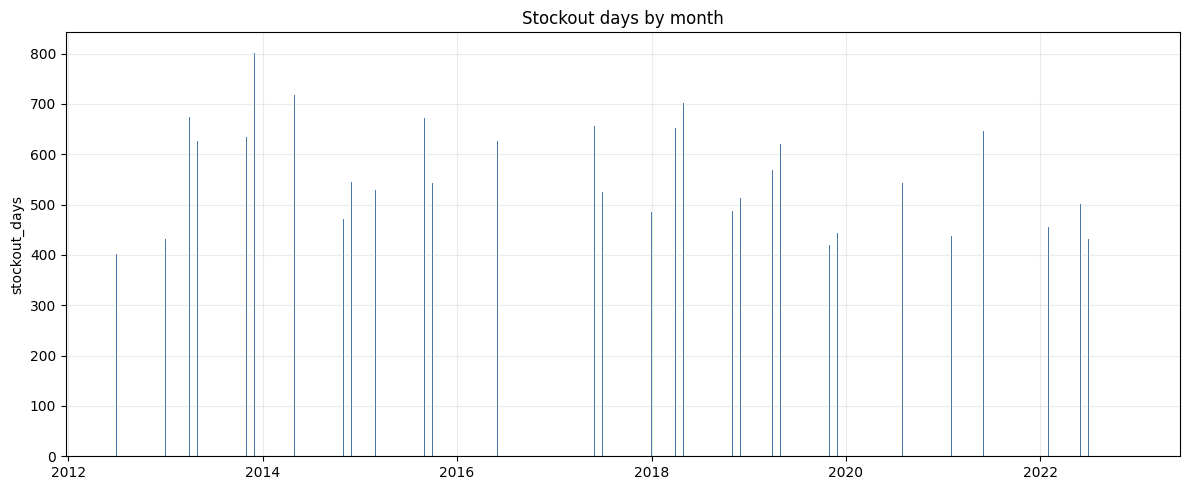

In [9]:
if monthly_stockout.empty:
    print('Monthly stockout data is unavailable; monthly stockout trend analysis cannot be computed.')
else:
    metric = 'stockout_days' if 'stockout_days' in monthly_stockout.columns and monthly_stockout['stockout_days'].notna().any() else 'stockout_product_month_count'
    label = 'Stockout days by month' if metric == 'stockout_days' else 'Stockout product-month count by month'
    display(monthly_stockout[['year_month', metric, 'stockout_rate']].sort_values(metric, ascending=False).head(15))

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(monthly_stockout['month_start'], monthly_stockout[metric], color='#4C78A8')
    ax.set_title(label)
    ax.set_ylabel(metric)
    plt.tight_layout()
    plt.show()

## 10. Stockout Heatmap Category × Month

Display a category-by-month stockout matrix using matplotlib. The matrix is also shown numerically for reference.

year_month,2012-07,2012-08,2012-09,2012-10,2012-11,2012-12,2013-01,2013-02,2013-03,2013-04,2013-05,2013-06,2013-07,2013-08,2013-09,2013-10,2013-11,2013-12,2014-01,2014-02,2014-03,2014-04,2014-05,2014-06,2014-07,2014-08,2014-09,2014-10,2014-11,2014-12,2015-01,2015-02,2015-03,2015-04,2015-05,2015-06,2015-07,2015-08,2015-09,2015-10,2015-11,2015-12,2016-01,2016-02,2016-03,2016-04,2016-05,2016-06,2016-07,2016-08,2016-09,2016-10,2016-11,2016-12,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08,2018-09,2018-10,2018-11,2018-12,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,2019-11,2019-12,2020-01,2020-02,2020-03,2020-04,2020-05,2020-06,2020-07,2020-08,2020-09,2020-10,2020-11,2020-12,2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12,2022-01,2022-02,2022-03,2022-04,2022-05,2022-06,2022-07,2022-08,2022-09,2022-10,2022-11,2022-12
category_final,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Casual,0.7500,0.5294,0.6471,0.2941,0.6250,0.7222,0.6471,0.6667,0.6471,0.8235,0.5333,0.7059,0.7333,0.5625,0.6471,0.6111,1.0000,0.5625,0.7647,0.7333,0.5625,0.6667,0.6667,0.7895,0.7222,0.5882,0.7500,0.7647,0.5625,0.5000,0.7059,0.5333,0.5263,0.5714,0.8000,0.5263,0.5789,0.6111,0.6316,0.6316,0.6667,0.6842,0.9474,0.5556,0.4500,0.7619,0.6190,0.8636,0.8889,0.6364,0.7222,0.6500,0.6667,0.5714,0.6842,0.5238,0.6000,0.7273,0.6842,0.7083,0.5000,0.5238,0.7000,0.8148,0.7600,0.8462,0.7692,0.7037,0.6552,0.7742,0.6774,0.6774,0.8710,0.6389,0.5429,0.5946,0.7714,0.7027,0.6286,0.7000,0.6750,0.5957,0.5682,0.5814,0.5455,0.6667,0.6250,0.6923,0.7297,0.5806,0.7879,0.7059,0.6905,0.7143,0.6429,0.7429,0.6154,0.7727,0.6111,0.7941,0.7188,0.5312,0.4857,0.5250,0.6667,0.6667,0.6939,0.5625,0.6341,0.6818,0.6667,0.5385,0.6333,0.7179,0.5946,0.6053,0.6750,0.7000,0.7073,0.6757,0.7143,0.6585,0.5641,0.6486,0.7143,0.7750
GenZ,0.8000,0.7000,0.8421,0.6000,0.8000,0.6667,0.8000,0.5882,0.6364,0.6190,0.5455,0.7500,0.5862,0.8696,0.6154,0.6000,0.6364,0.8750,0.8000,0.6190,0.8148,0.7586,0.7500,0.7097,0.7333,0.6250,0.7586,0.6957,0.6667,0.7273,0.6500,0.6522,0.6296,0.7576,0.7333,0.7333,0.7742,0.7297,0.6944,0.8158,0.7419,0.5806,0.7931,0.6774,0.7273,0.6061,0.6216,0.5641,0.8333,0.5882,0.7586,0.5882,0.4828,0.8378,0.8214,0.6250,0.7353,0.7778,0.7368,0.7500,0.6750,0.7317,0.6389,0.6216,0.6296,0.7297,0.5625,0.5806,0.7105,0.7727,0.6591,0.6596,0.6364,0.7442,0.5750,0.7317,0.6970,0.7419,0.5667,0.6757,0.5957,0.7292,0.6275,0.7843,0.5800,0.7358,0.6087,0.7347,0.6750,0.6098,0.7000,0.6944,0.6522,0.6481,0.7451,0.6792,0.6316,0.6923,0.7021,0.6522,0.6279,0.6486,0.7812,0.6829,0.5714,0.6316,0.6545,0.8065,0.6552,0.6429,0.6792,0.7660,0.5581,0.6250,0.6190,0.6444,0.6667,0.7414,0.7193,0.7167,0.7719,0.6167,0.6346,0.7273,0.6190,0.5682
Outdoor,0.6000,0.6954,0.6319,0.6325,0.7024,0.7173,0.6000,0.6848,0.7062,0.7059,0.6944,0.6983,0.7337,0.6790,0.6069,0.6763,0.6517,0.7111,0.7000,0.6831,0.6278,0.6613,0.7333,0.6510,0.6395,0.6289,0.6839,0.7459,0.6968,0.6788,0.7173,0.6301,0.6374,0.6961,0.6931,0.6461,0.6961,0.6277,0.7059,0.6649,0.7344,0.6976,0.7071,0.7011,0.7068,0.6383,0.7554,0.6437,0.6610,0.6939,0.6811,0.6393,0.7050,0.6878,0.7188,0.6722,0.7173,0.6075,0.6667,0.7053,0.6444,0.6456,0.6771,0.6753,0.6700,0.6599,0.6330,0.6721,0.6818,0.6875,0.6842,0.6949,0.6564,0.6059,0.6250,0.6306,0.6133,0.6349,0.6127,0.6437,0.6875,0.7143,0.6848,0.7544,0.6842,0.6829,0.5686,0.7114,0.6815,0.6265,0.5827,0.6929,0.6573,0.6826,0.6159,0.7500,0.6691,0.6770,0.7172,0.6466,0.7063,0.6503,0.6589,0.6241,0.6722,0.6852,0.7364,0.6978,0.6068,0.7442,0.6446,0.5659,0.6838,0.6987,0.5714,0.7209,0.6519,0.7343,0.6667,0.6825,0.6852,0.6519,0.6783,0.7016,0.7333,0.6597
Streetwear,0.6986,0.7319,0.6400,0.6838,0.7311,0.6937,0.6574,0.7455,0.7155,0.6969,0.6926,0.6280,0.6641,0.6260,0.6766,0.6938,0.6831,0.6680,0.6637,0.6612,0.6860,0.7312,0.6767,0.

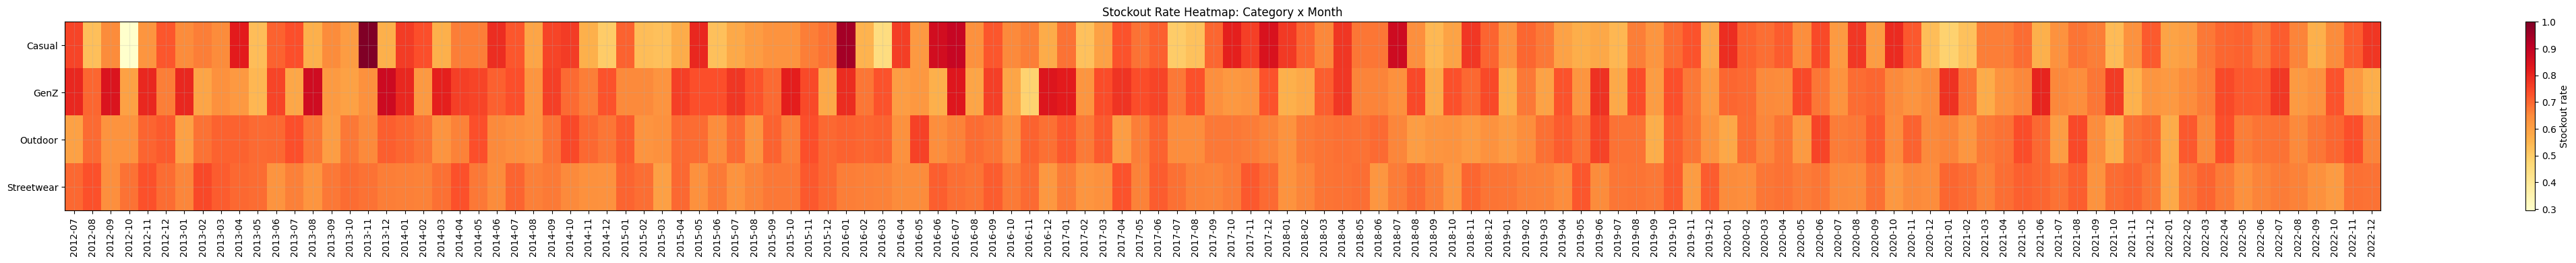

In [10]:
heatmap_matrix = pd.DataFrame()
if category_month_stockout.empty:
    print('Category-month stockout data is unavailable; heatmap cannot be computed.')
else:
    top_categories = category_stockout.head(10)['category_final'].tolist() if not category_stockout.empty else category_month_stockout['category_final'].value_counts().head(10).index.tolist()
    heatmap_matrix = category_month_stockout[category_month_stockout['category_final'].isin(top_categories)].pivot(index='category_final', columns='year_month', values='stockout_rate').fillna(0)
    display(heatmap_matrix)

    fig, ax = plt.subplots(figsize=(max(10, heatmap_matrix.shape[1] * 0.35), max(4, heatmap_matrix.shape[0] * 0.45)))
    im = ax.imshow(heatmap_matrix.values, aspect='auto', cmap='YlOrRd')
    ax.set_title('Stockout Rate Heatmap: Category x Month')
    ax.set_xticks(np.arange(heatmap_matrix.shape[1]))
    ax.set_xticklabels(heatmap_matrix.columns, rotation=90)
    ax.set_yticks(np.arange(heatmap_matrix.shape[0]))
    ax.set_yticklabels(heatmap_matrix.index)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Stockout rate')
    plt.tight_layout()
    plt.show()

## 11. Monthly Revenue Preparation

Aggregate Revenue by month and flag unusually low Revenue months using percentile, z-score, and rolling-mean deviation signals.

In [11]:
monthly_revenue = pd.DataFrame()
daily_revenue = pd.DataFrame()

if sales_raw is None or sales_raw.empty or cols.get('sales_date') is None or cols.get('revenue') is None:
    print('Sales data is unavailable or Revenue could not be identified; Revenue preparation cannot be computed.')
else:
    sa = sales_raw.copy()
    sa['date'] = pd.to_datetime(sa[cols['sales_date']], errors='coerce').dt.floor('D')
    sa['revenue'] = to_num(sa[cols['revenue']])
    daily_revenue = sa.dropna(subset=['date']).groupby('date', as_index=False)['revenue'].sum(min_count=1).sort_values('date')
    daily_revenue['year_month'] = daily_revenue['date'].dt.to_period('M').astype('string')

    monthly_revenue = daily_revenue.groupby('year_month', as_index=False).agg(
        revenue=('revenue', 'sum'),
        days=('date', 'count'),
    )
    monthly_revenue['month_start'] = pd.PeriodIndex(monthly_revenue['year_month'], freq='M').to_timestamp()
    rev_mean = monthly_revenue['revenue'].mean()
    rev_std = monthly_revenue['revenue'].std(ddof=0)
    monthly_revenue['revenue_z_score'] = (monthly_revenue['revenue'] - rev_mean) / rev_std if rev_std != 0 else 0
    monthly_revenue['revenue_roll_mean_3'] = monthly_revenue['revenue'].shift(1).rolling(3, min_periods=2).mean()
    low_pct = monthly_revenue['revenue'].quantile(0.10)
    monthly_revenue['low_revenue_flag'] = (
        (monthly_revenue['revenue'] <= low_pct) |
        (monthly_revenue['revenue_z_score'] <= -1.5) |
        (monthly_revenue['revenue_roll_mean_3'].notna() & (monthly_revenue['revenue'] < 0.85 * monthly_revenue['revenue_roll_mean_3']))
    )
    report = pd.DataFrame([
        {'metric': 'monthly_revenue_start', 'value': monthly_revenue['month_start'].min()},
        {'metric': 'monthly_revenue_end', 'value': monthly_revenue['month_start'].max()},
        {'metric': 'monthly_revenue_months', 'value': len(monthly_revenue)},
        {'metric': 'low_revenue_months_flagged', 'value': int(monthly_revenue['low_revenue_flag'].sum())},
    ])
    display(report)
    display(monthly_revenue)

,metric,value
0,monthly_revenue_start,2012-07-01 00:00:00
1,monthly_revenue_end,2022-12-01 00:00:00
2,monthly_revenue_months,126
3,low_revenue_months_flagged,61


,year_month,revenue,days,month_start,revenue_z_score,revenue_roll_mean_3,low_revenue_flag
0,2012-07,"130,406,773.5100",28,2012-07-01,0.0001,NaN,False
1,2012-08,"159,089,240.3100",31,2012-08-01,0.4930,NaN,False
2,2012-09,"129,307,133.8200",30,2012-09-01,-0.0188,"144,748,006.9100",False
3,2012-10,"110,185,694.4500",31,2012-10-01,-0.3474,"139,601,049.2133",True
4,2012-11,"98,186,295.2400",30,2012-11-01,-0.5536,"132,860,689.5267",True
...,...,...,...,...,...,...,...
121,2022-08,"113,542,943.4700",31,2022-08-01,-0.2897,"124,327,363.8567",False
122,2022-09,"85,764,286.5900",30,2022-09-01,-0.7670,"115,832,382.6267",True
123,2022-10,"75,194,452.3100",31,2022-10-01,-0.9486,"99,149,669.2600",True
124,2022-11,"52,200,081.6400",30,2022-11-01,-1.3438,"91,500,560.7900",True


## 12. Revenue vs Stockout Analysis

Merge monthly stockout metrics with monthly Revenue, compare low-Revenue months with stockout pressure, and calculate exploratory correlations.

,year_month,revenue,days,month_start,revenue_z_score,revenue_roll_mean_3,low_revenue_flag,total_product_month_records,stockout_product_month_count,number_of_stockout_products,average_inventory_qty,median_inventory_qty,average_fill_rate,stockout_days,stockout_days_per_product,stockout_rate
0,2012-07,"130,406,773.5100",28,2012-07-01,0.0001,NaN,False,395,264,264,59.9949,25.0000,0.9661,402,1.0177,0.6684
1,2012-08,"159,089,240.3100",31,2012-08-01,0.4930,NaN,False,423,300,300,62.0544,27.0000,0.9449,699,1.6525,0.7092
2,2012-09,"129,307,133.8200",30,2012-09-01,-0.0188,"144,748,006.9100",False,424,274,274,64.9033,30.0000,0.9500,636,1.5000,0.6462
3,2012-10,"110,185,694.4500",31,2012-10-01,-0.3474,"139,601,049.2133",True,437,282,282,66.8055,30.0000,0.9526,621,1.4211,0.6453
4,2012-11,"98,186,295.2400",30,2012-11-01,-0.5536,"132,860,689.5267",True,411,295,295,73.3187,34.0000,0.9599,495,1.2044,0.7178
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,2022-08,"113,542,943.4700",31,2022-08-01,-0.2897,"124,327,363.8567",False,461,301,301,227.5141,50.0000,0.9652,481,1.0434,0.6529
122,2022-09,"85,764,286.5900",30,2022-09-01,-0.7670,"115,832,382.6267",True,419,269,269,256.1074,60.0000,0.9670,415,0.9905,0.6420
123,2022-10,"75,194,452.3100",31,2022-10-01,-0.9486,"99,149,669.2600",True,409,268,268,254.9022,59.0000,0.9618,469,1.1467,0.6553
124,2022-11,"52,200,081.6400",30,2022-11-01,-1.3438,"91,500,560.7900",True,376,262,262,252.6676,56.0000,0.9599,452,1.2021,0.6968


,metric,correlation_with_monthly_revenue,valid_months
0,stockout_days,0.6490,126
1,stockout_product_month_count,0.6062,126
2,stockout_rate,0.1930,126
3,average_fill_rate,-0.4324,126


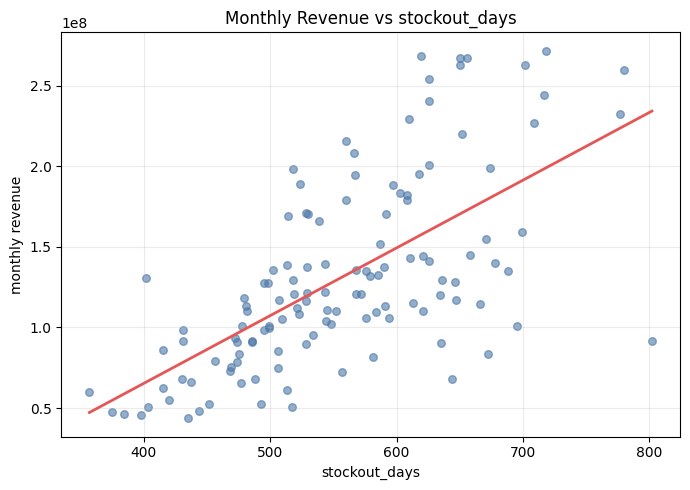

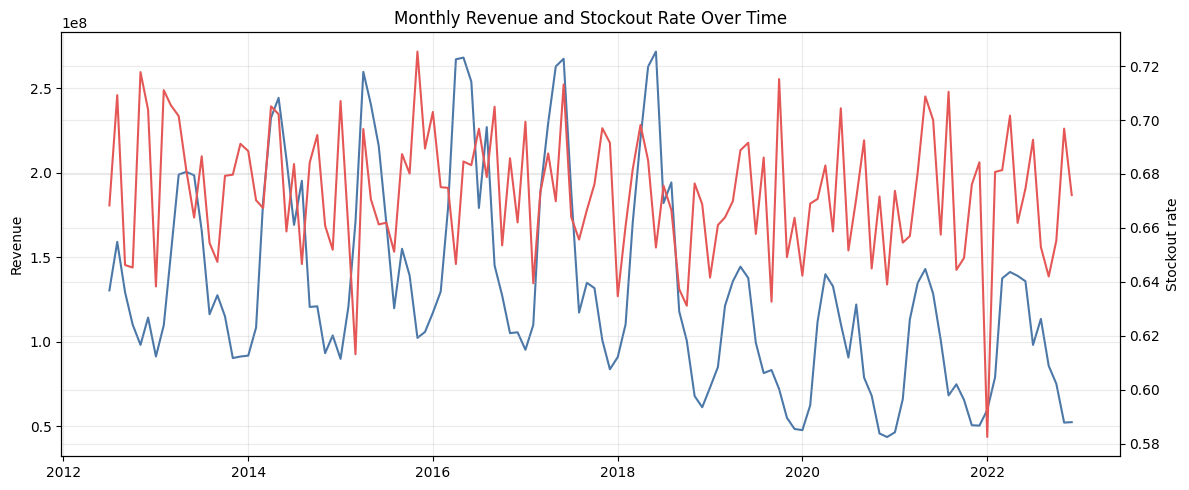

Low Revenue months with high stockout pressure:


,year_month,revenue,days,month_start,revenue_z_score,revenue_roll_mean_3,low_revenue_flag,total_product_month_records,stockout_product_month_count,number_of_stockout_products,average_inventory_qty,median_inventory_qty,average_fill_rate,stockout_days,stockout_days_per_product,stockout_rate
4,2012-11,"98,186,295.2400",30,2012-11-01,-0.5536,"132,860,689.5267",True,411,295,295,73.3187,34.0000,0.9599,495,1.2044,0.7178
17,2013-12,"91,285,868.4400",31,2013-12-01,-0.6721,"110,998,432.1767",True,476,329,329,111.6113,48.0000,0.9438,802,1.6849,0.6912
27,2014-10,"120,982,777.8700",31,2014-10-01,-0.1618,"161,681,768.7767",True,468,325,325,146.7137,63.0000,0.9595,568,1.2137,0.6944
30,2015-01,"89,880,637.0500",31,2015-01-01,-0.6963,"106,011,017.5300",True,454,321,321,153.0925,71.5000,0.9612,528,1.1630,0.7070
40,2015-11,"102,311,827.1600",30,2015-11-01,-0.4827,"138,038,880.9467",True,477,346,346,167.2243,80.0000,0.9617,548,1.1488,0.7254
41,2015-12,"105,849,396.4400",31,2015-12-01,-0.4219,"132,191,161.1233",True,483,333,333,172.1532,82.0000,0.9590,594,1.2298,0.6894
48,2016-07,"179,166,664.9300",31,2016-07-01,0.8380,"263,061,676.9000",True,498,347,347,193.2369,88.0000,0.9593,608,1.2209,0.6968
50,2016-09,"145,153,113.0400",30,2016-09-01,0.2535,"220,038,179.3000",True,488,344,344,193.5492,94.0000,0.9551,658,1.3484,0.7049
54,2017-01,"95,271,628.8300",31,2017-01-01,-0.6036,"112,693,896.8933",True,469,328,328,197.8124,90.0000,0.9620,534,1.1386,0.6994
64,2017-11,"100,958,873.2600",30,2017-11-01,-0.5059,"127,988,082.7467",True,495,345,345,210.0485,77.0000,0.9532,695,1.4040,0.6970


Low Revenue months without high stockout pressure:


,year_month,revenue,days,month_start,revenue_z_score,revenue_roll_mean_3,low_revenue_flag,total_product_month_records,stockout_product_month_count,number_of_stockout_products,average_inventory_qty,median_inventory_qty,average_fill_rate,stockout_days,stockout_days_per_product,stockout_rate
3,2012-10,"110,185,694.4500",31,2012-10-01,-0.3474,"139,601,049.2133",True,437,282,282,66.8055,30.0000,0.9526,621,1.4211,0.6453
6,2013-01,"91,308,677.0300",31,2013-01-01,-0.6717,"107,564,866.7933",True,423,270,270,79.3026,34.0000,0.9660,431,1.0189,0.6383
13,2013-08,"116,271,755.9600",31,2013-08-01,-0.2428,"188,254,364.0033",True,463,303,303,103.3801,48.0000,0.9620,528,1.1404,0.6544
14,2013-09,"127,534,147.9700",30,2013-09-01,-0.0493,"160,178,246.1633",True,485,314,314,101.5113,42.0000,0.9660,495,1.0206,0.6474
28,2014-11,"93,293,576.7800",30,2014-11-01,-0.6376,"145,623,378.8433",True,457,302,302,149.1160,65.0000,0.9656,472,1.0328,0.6608
36,2015-07,"170,237,048.4800",31,2015-07-01,0.6845,"238,638,500.8800",True,494,327,327,168.0101,78.0000,0.9642,530,1.0729,0.6619
37,2015-08,"119,854,986.6300",31,2015-08-01,-0.1812,"208,819,375.4200",True,516,336,336,157.3837,74.0000,0.9590,634,1.2287,0.6512
51,2016-10,"127,350,601.3400",31,2016-10-01,-0.0524,"183,776,089.9433",True,482,315,315,197.8568,94.0000,0.9656,498,1.0332,0.6535
53,2016-12,"105,617,010.0600",31,2016-12-01,-0.4259,"125,872,597.8867",True,503,333,333,191.8330,89.0000,0.9618,576,1.1451,0.6620
60,2017-07,"188,994,407.3300",31,2017-07-01,1.0068,"253,289,694.2533",True,515,342,342,203.8369,86.0000,0.9661,524,1.0175,0.6641


High stockout pressure months with normal Revenue:


,year_month,revenue,days,month_start,revenue_z_score,revenue_roll_mean_3,low_revenue_flag,total_product_month_records,stockout_product_month_count,number_of_stockout_products,average_inventory_qty,median_inventory_qty,average_fill_rate,stockout_days,stockout_days_per_product,stockout_rate
1,2012-08,"159,089,240.3100",31,2012-08-01,0.4930,NaN,False,423,300,300,62.0544,27.0000,0.9449,699,1.6525,0.7092
5,2012-12,"114,322,610.6900",31,2012-12-01,-0.2763,"112,559,707.8367",False,449,316,316,73.1024,29.0000,0.9506,666,1.4833,0.7038
7,2013-02,"109,783,137.9400",28,2013-02-01,-0.3543,"101,272,527.6533",False,443,315,315,79.1332,33.0000,0.9561,584,1.3183,0.7111
8,2013-03,"151,834,657.2700",31,2013-03-01,0.3683,"105,138,141.8867",False,455,321,321,80.8989,34.0000,0.9570,587,1.2901,0.7055
9,2013-04,"198,926,932.0900",30,2013-04-01,1.1775,"117,642,157.4133",False,479,336,336,82.1211,34.0000,0.9531,674,1.4071,0.7015
21,2014-04,"232,565,641.3000",30,2014-04-01,1.7556,"127,919,518.0133",False,512,361,361,116.7012,49.0000,0.9494,777,1.5176,0.7051
22,2014-05,"244,309,542.3200",31,2014-05-01,1.9574,"174,840,160.1533",False,507,356,356,123.2722,51.0000,0.9529,717,1.4142,0.7022
33,2015-04,"259,694,424.8600",30,2015-04-01,2.2217,"127,167,803.1200",False,511,356,356,144.1076,62.0000,0.9491,780,1.5264,0.6967
42,2016-01,"117,204,715.5800",31,2016-01-01,-0.2268,"115,797,401.0133",False,468,329,329,173.1496,83.0000,0.9639,507,1.0833,0.7030
59,2017-06,"267,433,341.6900",30,2017-06-01,2.3547,"226,939,395.6233",False,523,373,373,200.0038,79.0000,0.9582,656,1.2543,0.7132


In [12]:
monthly_rev_stock = pd.DataFrame()
if monthly_stockout.empty or monthly_revenue.empty:
    print('Monthly stockout or monthly Revenue data is unavailable; Revenue vs stockout analysis cannot be computed.')
else:
    monthly_rev_stock = monthly_revenue.merge(monthly_stockout, on=['year_month', 'month_start'], how='inner')
    display(monthly_rev_stock)

    corr_rows = []
    for metric in ['stockout_days', 'stockout_product_month_count', 'stockout_rate', 'average_fill_rate']:
        if metric in monthly_rev_stock.columns and monthly_rev_stock[metric].notna().sum() >= 2:
            valid = monthly_rev_stock[['revenue', metric]].replace([np.inf, -np.inf], np.nan).dropna()
            corr_rows.append({'metric': metric, 'correlation_with_monthly_revenue': valid['revenue'].corr(valid[metric]) if len(valid) >= 2 else np.nan, 'valid_months': len(valid)})
    corr_table = pd.DataFrame(corr_rows)
    display(corr_table)

    x_metric = 'stockout_days' if 'stockout_days' in monthly_rev_stock.columns and monthly_rev_stock['stockout_days'].notna().any() else 'stockout_product_month_count'
    fig, ax = plt.subplots(figsize=(7, 5))
    sample = monthly_rev_stock[[x_metric, 'revenue']].replace([np.inf, -np.inf], np.nan).dropna()
    ax.scatter(sample[x_metric], sample['revenue'], alpha=0.6, s=30, color='#4C78A8')
    if len(sample) >= 2 and sample[x_metric].nunique() > 1:
        coeff = np.polyfit(sample[x_metric], sample['revenue'], 1)
        x_line = np.linspace(sample[x_metric].min(), sample[x_metric].max(), 100)
        ax.plot(x_line, coeff[0] * x_line + coeff[1], color='#E45756', linewidth=2)
    ax.set_title(f'Monthly Revenue vs {x_metric}')
    ax.set_xlabel(x_metric)
    ax.set_ylabel('monthly revenue')
    plt.tight_layout()
    plt.show()

    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.plot(monthly_rev_stock['month_start'], monthly_rev_stock['revenue'], color='#4C78A8', label='Revenue')
    ax1.set_ylabel('Revenue')
    ax2 = ax1.twinx()
    ax2.plot(monthly_rev_stock['month_start'], monthly_rev_stock['stockout_rate'], color='#E45756', label='Stockout rate')
    ax2.set_ylabel('Stockout rate')
    ax1.set_title('Monthly Revenue and Stockout Rate Over Time')
    plt.tight_layout()
    plt.show()

    low_rev_high_stock = monthly_rev_stock[(monthly_rev_stock['low_revenue_flag']) & (monthly_rev_stock['stockout_rate'] >= monthly_rev_stock['stockout_rate'].quantile(0.75))]
    low_rev_no_stock = monthly_rev_stock[(monthly_rev_stock['low_revenue_flag']) & (monthly_rev_stock['stockout_rate'] < monthly_rev_stock['stockout_rate'].quantile(0.50))]
    high_stock_normal_rev = monthly_rev_stock[(~monthly_rev_stock['low_revenue_flag']) & (monthly_rev_stock['stockout_rate'] >= monthly_rev_stock['stockout_rate'].quantile(0.75))]
    print('Low Revenue months with high stockout pressure:')
    display(low_rev_high_stock)
    print('Low Revenue months without high stockout pressure:')
    display(low_rev_no_stock)
    print('High stockout pressure months with normal Revenue:')
    display(high_stock_normal_rev)

## 13. Best-Selling Product Stockout Check

If product-level sales are unavailable in `sales.csv`, note the limitation clearly. When possible, an inventory-side `units_sold` proxy is used only as an approximation, not as exact product-level Revenue.

In [13]:
best_seller_stockout = pd.DataFrame()
if sales_raw is None or cols.get('sales_product_id') is None:
    print('sales.csv does not expose product-level sales IDs in this dataset, so best-selling product stockout analysis cannot be fully performed from the listed files.')
    if 'units_sold_raw' in inventory_joined.columns and inventory_joined['units_sold_raw'].notna().any():
        approx = inventory_joined.groupby('product_id_std').agg(
            approx_units_sold=('units_sold_raw', 'sum'),
            stockout_count=('stockout_flag_final', lambda s: int(s.fillna(False).sum())),
            stockout_days=('stockout_days_raw', 'sum'),
            category=('category_final', 'first'),
        ).reset_index().sort_values('approx_units_sold', ascending=False)
        best_seller_stockout = approx.head(20)
        print('Approximate best-selling products using inventory-side units_sold proxy:')
        display(best_seller_stockout)
else:
    print('Product-level sales were identified; add product-level revenue logic here if needed.')

sales.csv does not expose product-level sales IDs in this dataset, so best-selling product stockout analysis cannot be fully performed from the listed files.
Approximate best-selling products using inventory-side units_sold proxy:


,product_id_std,approx_units_sold,stockout_count,stockout_days,category
1504,792,13149,67,156,Outdoor
1503,791,13149,77,177,Outdoor
1358,604,10506,90,132,Streetwear
799,2045,10376,78,116,Streetwear
1244,487,9623,48,82,Streetwear
983,2332,9386,80,121,Streetwear
155,1182,9242,93,140,Streetwear
1206,438,9124,58,174,Streetwear
1569,927,9002,79,120,Streetwear
1528,826,8315,73,110,Streetwear


## 14. Merge Monthly Inventory Signals into Daily Revenue Data

Lag month-level inventory features by one month before merging them into daily Revenue rows by year-month. This means each daily row receives the previous month's realized inventory signal, which is leakage-safe when future/current month inventory status is not known in advance.

In [14]:
daily_with_inventory = pd.DataFrame()
monthly_features = pd.DataFrame()

if monthly_stockout.empty or daily_revenue.empty:
    print('Monthly inventory or daily Revenue data is unavailable; lagged inventory merge cannot be computed.')
else:
    monthly_features = monthly_stockout[['year_month', 'month_start', 'stockout_days', 'stockout_product_month_count', 'stockout_rate', 'average_fill_rate', 'average_inventory_qty']].copy()
    monthly_features = monthly_features.sort_values('month_start')
    monthly_features['stockout_days_lag_month'] = monthly_features['stockout_days'].shift(1)
    monthly_features['stockout_count_lag'] = monthly_features['stockout_product_month_count'].shift(1)
    monthly_features['stockout_rate_lag'] = monthly_features['stockout_rate'].shift(1)
    monthly_features['avg_fill_rate_lag'] = monthly_features['average_fill_rate'].shift(1)
    monthly_features['avg_inventory_qty_lag'] = monthly_features['average_inventory_qty'].shift(1)
    monthly_features['stockout_pressure_roll_mean_3m'] = monthly_features['stockout_rate'].shift(1).rolling(3, min_periods=2).mean()

    # Category-level pressure proxy: previous month's max category stockout rate.
    if not category_month_stockout.empty:
        cat_pressure = category_month_stockout.groupby('year_month')['stockout_rate'].max().reset_index(name='category_stockout_pressure')
        monthly_features = monthly_features.merge(cat_pressure, on='year_month', how='left')
        monthly_features['category_stockout_pressure_lag'] = monthly_features['category_stockout_pressure'].shift(1)

    lag_cols = [c for c in monthly_features.columns if c.endswith('_lag') or c.endswith('_lag_month') or c.endswith('_3m')]
    daily_with_inventory = daily_revenue.merge(monthly_features[['year_month'] + lag_cols + ([c for c in ['category_stockout_pressure_lag'] if c in monthly_features.columns])], on='year_month', how='left')
    display(daily_with_inventory.head(20))

,date,revenue,year_month,stockout_days_lag_month,stockout_count_lag,stockout_rate_lag,avg_fill_rate_lag,avg_inventory_qty_lag,stockout_pressure_roll_mean_3m,category_stockout_pressure_lag,category_stockout_pressure_lag
0,2012-07-04,"5,123,547.9400",2012-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-07-05,"2,751,773.4500",2012-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2012-07-06,"3,054,029.4200",2012-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2012-07-07,"2,667,930.9400",2012-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2012-07-08,"2,360,851.9000",2012-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2012-07-09,"3,548,386.4600",2012-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2012-07-10,"5,234,938.6200",2012-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2012-07-11,"5,582,884.7800",2012-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2012-07-12,"5,734,632.0200",2012-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2012-07-13,"5,309,511.7100",2012-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 15. Leakage-Safe Stockout Forecast Feature Preview

Display the final daily feature preview. Monthly inventory signals are shifted before merging, so a daily row in month `M` receives the previous month's realized inventory signal unless current/future month inventory status is known in advance.

In [15]:
feature_preview = pd.DataFrame()
feature_registry = pd.DataFrame()
if daily_with_inventory.empty:
    print('Daily Revenue with lagged monthly inventory features is unavailable; feature preview cannot be built.')
else:
    feature_preview = daily_with_inventory.copy()
    preview_cols = ['date', 'revenue', 'year_month', 'stockout_days_lag_month', 'stockout_count_lag', 'stockout_rate_lag', 'avg_fill_rate_lag', 'avg_inventory_qty_lag']
    for c in ['category_stockout_pressure_lag', 'stockout_pressure_roll_mean_3m']:
        if c in feature_preview.columns:
            preview_cols.append(c)
    preview_cols = [c for c in preview_cols if c in feature_preview.columns]
    display(feature_preview[preview_cols].head(40))

    same_month_known_only = ['stockout_days', 'stockout_product_month_count', 'stockout_rate', 'average_fill_rate', 'average_inventory_qty']
    historical_safe = [c for c in feature_preview.columns if c.endswith('_lag_month') or c.endswith('_lag') or c.endswith('_3m')]
    feature_registry = pd.DataFrame({
        'feature': same_month_known_only + historical_safe,
        'feature_type': ['requires known current/future inventory status'] * len(same_month_known_only) + ['historical lagged monthly only'] * len(historical_safe),
        'forecast_use_note': ['Use only when current/future inventory plans or known stock status are genuinely available before prediction.'] * len(same_month_known_only) + ['Leakage-safe because this value is shifted to prior month history before daily merge.'] * len(historical_safe),
    })
    display(feature_registry)

,date,revenue,year_month,stockout_days_lag_month,stockout_count_lag,stockout_rate_lag,avg_fill_rate_lag,avg_inventory_qty_lag,category_stockout_pressure_lag,category_stockout_pressure_lag,stockout_pressure_roll_mean_3m
0,2012-07-04,"5,123,547.9400",2012-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-07-05,"2,751,773.4500",2012-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2012-07-06,"3,054,029.4200",2012-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2012-07-07,"2,667,930.9400",2012-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2012-07-08,"2,360,851.9000",2012-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2012-07-09,"3,548,386.4600",2012-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2012-07-10,"5,234,938.6200",2012-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2012-07-11,"5,582,884.7800",2012-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2012-07-12,"5,734,632.0200",2012-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2012-07-13,"5,309,511.7100",2012-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,feature,feature_type,forecast_use_note
0,stockout_days,requires known current/future inventory status,Use only when current/future inventory plans o...
1,stockout_product_month_count,requires known current/future inventory status,Use only when current/future inventory plans o...
2,stockout_rate,requires known current/future inventory status,Use only when current/future inventory plans o...
3,average_fill_rate,requires known current/future inventory status,Use only when current/future inventory plans o...
4,average_inventory_qty,requires known current/future inventory status,Use only when current/future inventory plans o...
5,stockout_days_lag_month,historical lagged monthly only,Leakage-safe because this value is shifted to ...
6,stockout_count_lag,historical lagged monthly only,Leakage-safe because this value is shifted to ...
7,stockout_rate_lag,historical lagged monthly only,Leakage-safe because this value is shifted to ...
8,avg_fill_rate_lag,historical lagged monthly only,Leakage-safe because this value is shifted to ...
9,avg_inventory_qty_lag,historical lagged monthly only,Leakage-safe because this value is shifted to ...


## 16. Key Observations and Warnings

Final concise summary with stockout concentration, low-Revenue overlap, product-level limitations, recommended features, and leakage cautions.

In [16]:
def fmt(x, digits=4):
    return 'n/a' if pd.isna(x) else f'{x:,.{digits}f}'

summary_lines = []

if not category_stockout.empty:
    top_cats = category_stockout.head(5)
    summary_lines.append('Categories with the highest stockout rate: ' + ', '.join(f"{r.category_final} ({r.stockout_rate:.2%})" for r in top_cats.itertuples()))
else:
    summary_lines.append('Category-level stockout rates could not be computed because category data was unavailable.')

if not monthly_stockout.empty:
    metric = 'stockout_days' if 'stockout_days' in monthly_stockout.columns and monthly_stockout['stockout_days'].notna().any() else 'stockout_product_month_count'
    top_months = monthly_stockout.sort_values(metric, ascending=False).head(5)
    summary_lines.append('Months with the highest stockout pressure: ' + ', '.join(f"{r.year_month} ({metric}={getattr(r, metric):,.2f})" for r in top_months.itertuples()))

if not monthly_rev_stock.empty:
    overlap_count = int(((monthly_rev_stock['low_revenue_flag']) & (monthly_rev_stock['stockout_rate'] >= monthly_rev_stock['stockout_rate'].quantile(0.75))).sum())
    summary_lines.append(f'High stockout periods overlapping unusually low Revenue months: {overlap_count}.')
    corr_value = np.nan
    for metric in ['stockout_rate', 'stockout_product_month_count', 'stockout_days']:
        if metric in monthly_rev_stock.columns and monthly_rev_stock[metric].notna().sum() >= 2:
            valid = monthly_rev_stock[['revenue', metric]].dropna()
            if len(valid) >= 2:
                corr_value = valid['revenue'].corr(valid[metric])
                break
    if pd.notna(corr_value):
        strength = 'strong' if abs(corr_value) >= 0.5 else ('weak' if abs(corr_value) < 0.2 else 'unclear')
        summary_lines.append(f'The observed monthly stockout-pressure versus Revenue relationship appears {strength} under simple correlation checks.')

if not best_seller_stockout.empty:
    summary_lines.append('Best-selling product stockout check used inventory-side units_sold as an approximation because sales.csv is aggregate-only in this dataset.')
else:
    summary_lines.append('Best-selling product stockout analysis cannot be fully performed from the listed files because sales.csv does not contain product-level sales IDs.')

if inventory_warnings:
    summary_lines.append('Inventory data quality warnings: ' + '; '.join(inventory_warnings))
else:
    summary_lines.append('Inventory data quality warnings: none beyond the checks reported in the notebook tables.')

summary_lines.append('Recommended leakage-safe stockout forecast features: stockout_days_lag_month, stockout_count_lag, stockout_rate_lag, avg_fill_rate_lag, avg_inventory_qty_lag, category_stockout_pressure_lag, and stockout_pressure_roll_mean_3m.')
summary_lines.append('Monthly inventory features should be lagged before merging into daily Revenue data unless current/future inventory status is known before prediction.')
summary_lines.append('Causal caution: this is observational EDA. Stockouts and Revenue can move together because of seasonality, demand spikes, assortment changes, pricing, promotions, and replenishment timing.')

print('KEY OBSERVATIONS AND WARNINGS')
for line in summary_lines:
    print('-', line)

KEY OBSERVATIONS AND WARNINGS
- Categories with the highest stockout rate: GenZ (68.29%), Outdoor (67.35%), Streetwear (67.32%), Casual (66.20%)
- Months with the highest stockout pressure: 2013-12 (stockout_days=802.00), 2015-04 (stockout_days=780.00), 2014-04 (stockout_days=777.00), 2018-06 (stockout_days=718.00), 2014-05 (stockout_days=717.00)
- High stockout periods overlapping unusually low Revenue months: 16.
- The observed monthly stockout-pressure versus Revenue relationship appears weak under simple correlation checks.
- Best-selling product stockout check used inventory-side units_sold as an approximation because sales.csv is aggregate-only in this dataset.
- Inventory data quality warnings: none beyond the checks reported in the notebook tables.
- Recommended leakage-safe stockout forecast features: stockout_days_lag_month, stockout_count_lag, stockout_rate_lag, avg_fill_rate_lag, avg_inventory_qty_lag, category_stockout_pressure_lag, and stockout_pressure_roll_mean_3m.
- Mo